# Data Preprocessing & Feature Engineering

Real-estate datasets often contain missing values, heterogeneous feature scales, and categorical variables that are incompatible with most machine learning algorithms.

The goal of this notebook is to transform raw housing data into a clean, consistent, and model-ready dataset while minimizing information loss and bias.

## 1. Data Import & Initial Exploration
In this section, we load the necessary libraries and the raw housing dataset. We also perform an initial exploration of the dataset's shape and the distribution of our target variable, `SalePrice`.

In [1]:
# Import standard data manipulation and visualization libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Import statistical and preprocessing tools
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from scipy import stats

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the raw dataset
df = pd.read_csv('../data/raw/df.csv')

# Set 'Id' as the dataframe index since it has no predictive value
df = df.set_index('Id') 

# Display the dimensions of the dataset (rows, columns)
df.shape

(1460, 80)

The first thing we can notice is that we have 79 variable (which is a lot) + the target

In [3]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Analyze the statistical summary of the target variable
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice', ylabel='Density'>

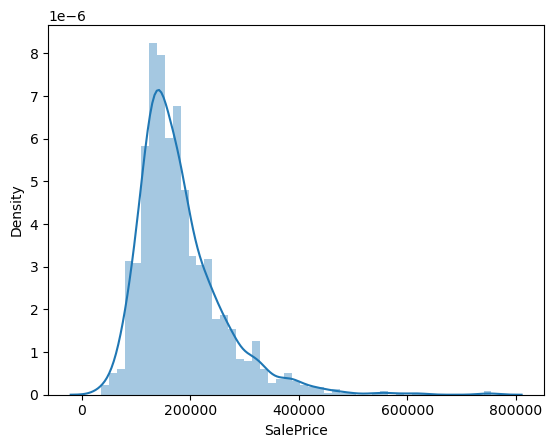

In [5]:
# Visualize the distribution of the target variable
sns.distplot(df['SalePrice'])

The distribution of the target variable "SalePrice" shows that we have a big price range (35k to 755k), which may be a sign of the presence of outliers (especially in high prices).
This big range will also be the reason why we will not rely on RMSE as our main loss metric. In the modeling step, we will add RMSLE(Root Mean Squared Logarithmic Error) to better handle the multiple orders of magnitude.

## 2. Handling Missing Values: High Nullity Columns
Features with an overwhelming majority of missing values often add noise rather than predictive power. Here, we identify and drop columns that are too sparse to be useful.

In [6]:
# Calculate and display the percentage of missing values per column (filtering for > 0%)
(df.isnull().sum()[df.isnull().sum() > 0] / len(df) * 100).round(2)

LotFrontage     17.74
Alley           93.77
MasVnrType      59.73
MasVnrArea       0.55
BsmtQual         2.53
BsmtCond         2.53
BsmtExposure     2.60
BsmtFinType1     2.53
BsmtFinType2     2.60
Electrical       0.07
FireplaceQu     47.26
GarageType       5.55
GarageYrBlt      5.55
GarageFinish     5.55
GarageQual       5.55
GarageCond       5.55
PoolQC          99.52
Fence           80.75
MiscFeature     96.30
dtype: float64

In [7]:
# We remove any variable with at least 45% missing values
df = df.drop(columns=['Alley','MasVnrType','FireplaceQu','PoolQC','Fence','MiscFeature'])

### Handling the rest will be done in next steps based if the feature is categorical or numerical.

## 3. Removing Low Variance Features
Features that have the exact same value for almost all observations (zero or near-zero variance) do not help machine learning models differentiate between patterns. We will identify and remove these features.

In [8]:
# Check if there are any completely constant columns
df.columns[df.nunique() == 1]

Index([], dtype='object')

### 3.1 categorical features

In [9]:
# Identify categorical features where more than 95% of the values belong to a single category
threshold = 0.05  # 05% variation threshold
low_var_cols1 = [col for col in df.columns if df[col].value_counts(normalize=True).iloc[0] > (1 - threshold)]
low_var_cols1

['Street',
 'Utilities',
 'Condition2',
 'RoofMatl',
 'Heating',
 'LowQualFinSF',
 'KitchenAbvGr',
 'GarageQual',
 'GarageCond',
 '3SsnPorch',
 'PoolArea',
 'MiscVal']

In [10]:
# Example check: Verify the severe imbalance in the 'Utilities' column
df['Utilities'].value_counts(normalize=True)

Utilities
AllPub    0.999315
NoSeWa    0.000685
Name: proportion, dtype: float64

In [11]:
# Drop the identified low-variance categorical features
df = df.drop(columns=low_var_cols1)

In [12]:
df.shape

(1460, 62)

### 3.2 numerical features

In [13]:
# Initialize VarianceThreshold to find low-variance numerical features
num_df = df.select_dtypes(include=['int64', 'float64'])
selector = VarianceThreshold(threshold=0.05)  # keep features with variance > 0.05
selector.fit(num_df)

# Extract numerical columns that failed the variance threshold
low_var_cols2 = num_df.columns[~selector.get_support()]
low_var_cols2

Index([], dtype='object')

## 4. Dealing with outliers

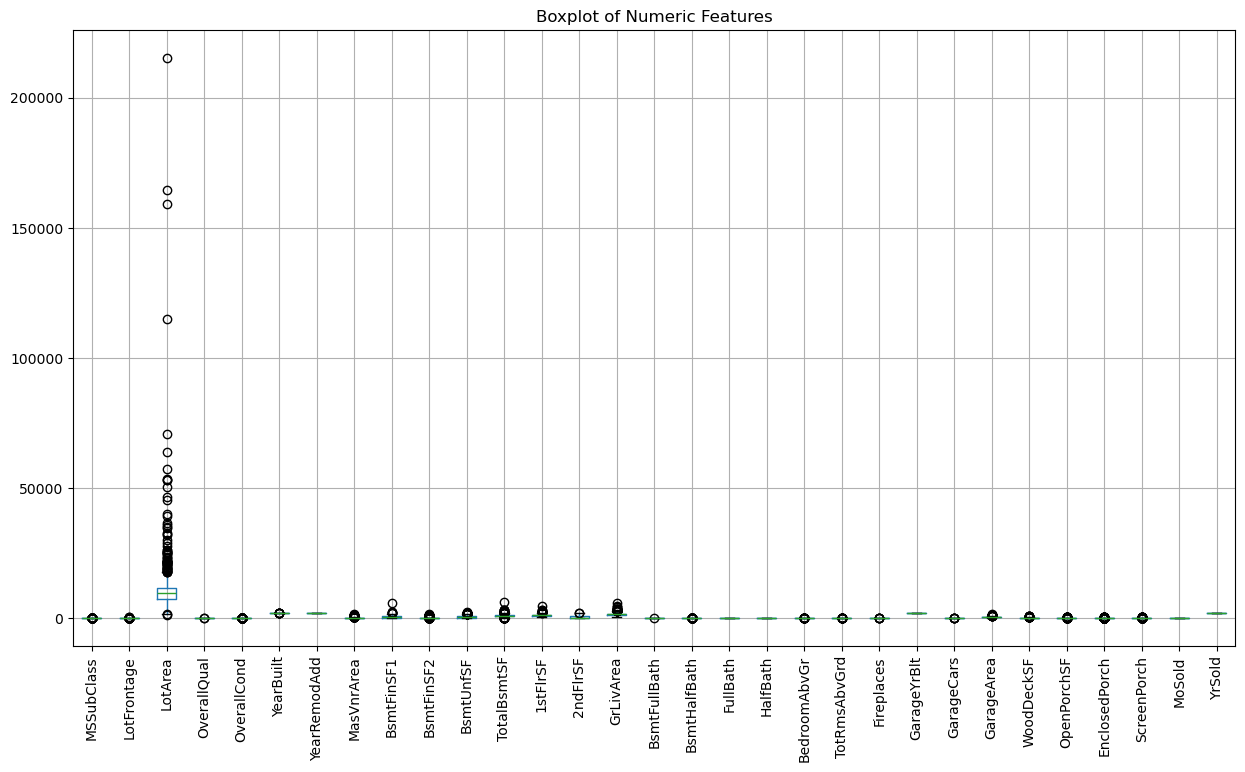

In [14]:
# Choose numeric columns only
num_cols = df.drop(columns=['SalePrice']).select_dtypes(include=['int64', 'float64']).columns

# Plot boxplots
plt.figure(figsize=(15, 8))
df[num_cols].boxplot(rot=90)
plt.title("Boxplot of Numeric Features")
plt.show()

In [15]:
# Given the small dataset we have, we fixed the zscore outlier threshold to 4 instead of 3.  
z_scores = np.abs(stats.zscore(df[num_cols]))
outlier_rows = (z_scores > 4).any(axis=1)
df_outliers = df[outlier_rows]

print(f"Total rows with at least one EXTREME outlier: {df_outliers.shape[0]}")

Total rows with at least one EXTREME outlier: 95


In [16]:
# Create cleaned dataframe (without outliers)
df_2 = df[~outlier_rows].copy()

In [17]:
df_2.shape

(1365, 62)

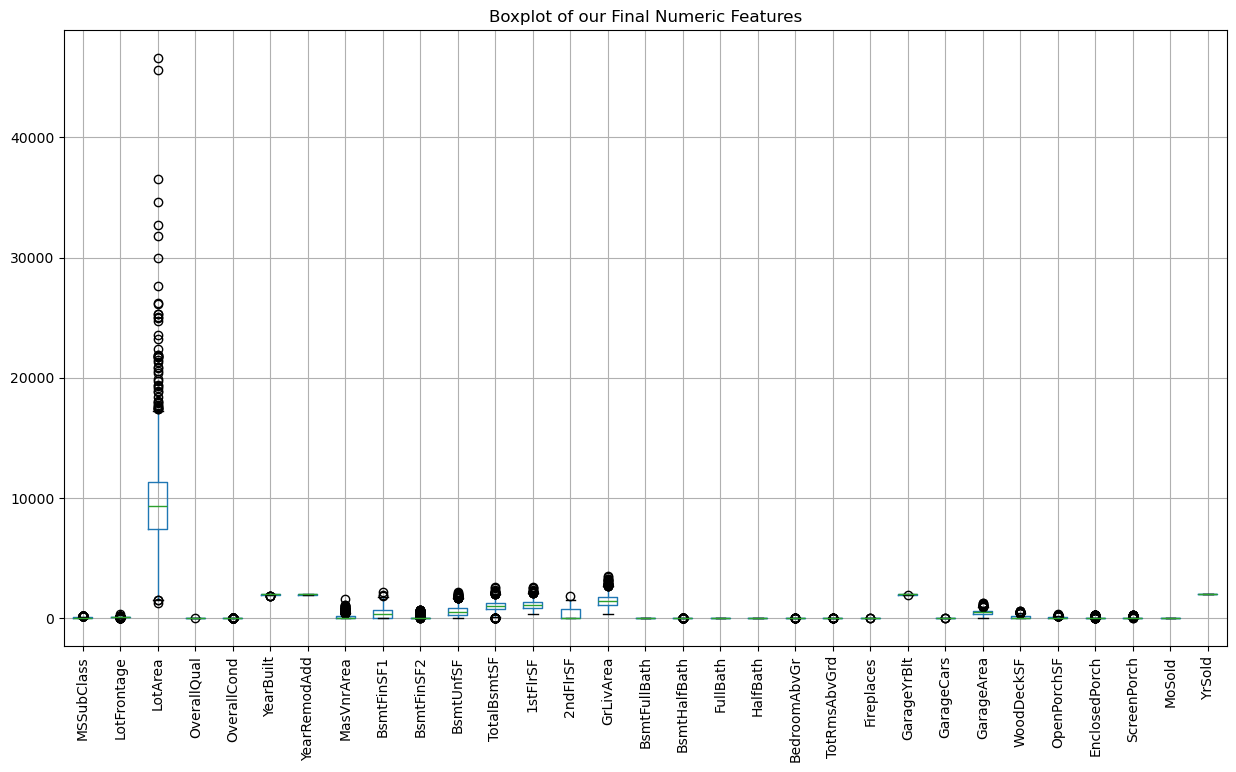

In [18]:
# Plot boxplots
plt.figure(figsize=(15, 8))
df_2[num_cols].boxplot(rot=90)
plt.title("Boxplot of our Final Numeric Features")
plt.show()

#### We can see that the "LotArea" maximun is now arround 500k instead of 2M before.

## 5. Encoding Categorical Features

In [19]:
df_2.select_dtypes(include=['object']).isnull().sum()[df_2.isnull().sum() > 0] 

BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    37
Electrical       1
GarageType      75
GarageFinish    75
dtype: int64

In [20]:
df_2.select_dtypes(include=['object'])

,MSZoning,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,BldgType,HouseStyle,RoofStyle,...,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,GarageType,GarageFinish,PavedDrive,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1,RL,Reg,Lvl,Inside,Gtl,CollgCr,Norm,1Fam,2Story,Gable,...,Ex,Y,SBrkr,Gd,Typ,Attchd,RFn,Y,WD,Normal
2,RL,Reg,Lvl,FR2,Gtl,Veenker,Feedr,1Fam,1Story,Gable,...,Ex,Y,SBrkr,TA,Typ,Attchd,RFn,Y,WD,Normal
3,RL,IR1,Lvl,Inside,Gtl,CollgCr,Norm,1Fam,2Story,Gable,...,Ex,Y,SBrkr,Gd,Typ,Attchd,RFn,Y,WD,Normal
5,RL,IR1,Lvl,FR2,Gtl,NoRidge,Norm,1Fam,2Story,Gable,...,Ex,Y,SBrkr,Gd,Typ,Attchd,RFn,Y,WD,Normal
6,RL,IR1,Lvl,Inside,Gtl,Mitchel,Norm,1Fam,1.5Fin,Gable,...,Ex,Y,SBrkr,TA,Typ,Attchd,Unf,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,RL,Reg,Lvl,Inside,Gtl,Mitchel,Norm,1Fam,1Story,Gable,...,Ex,Y,SBrkr,TA,Typ,NaN,NaN,Y,WD,Abnorml
1455,FV,Reg,Lvl,Inside,Gtl,Somerst,Norm,1Fam,1Story,Gable,...,Ex,Y,SBrkr,Gd,Typ,Attchd,RFn,Y,WD,Normal
1456,RL,Reg,Lvl,Inside,Gtl,Gilbert,Norm,1Fam,2Story,Gable,...,Ex,Y,SBrkr,TA,Typ,Attchd,RFn,Y,WD,Normal


In [21]:
df_2.select_dtypes(include=['object']).columns

Index(['MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle',
       'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'PavedDrive', 'SaleType',
       'SaleCondition'],
      dtype='object')

#### We have 30 categorical Features (8 of them with missing values). Let's find which ones are ordinal and which are only nominal.

In [22]:
# List of columns
cols = [
    'MSZoning', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle',
       'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'PavedDrive', 'SaleType',
       'SaleCondition'
]

# Loop through each and print value counts
for col in cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- MSZoning ---
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

--- LotShape ---
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

--- LandContour ---
LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

--- LotConfig ---
LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

--- LandSlope ---
LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

--- Neighborhood ---
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
StoneBr     25
SWISU       25
MeadowV     17
Blmngtn     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64



## Handling missing values (Part 2)

In [23]:
# First let's replace the missing values in categorical Features with "NA".
for col in cols:
    df_2[col].fillna('NA', inplace=True)

In [24]:
# And the missing values in numerical features.
df_2.isnull().sum()[df_2.isnull().sum() > 0] 

LotFrontage    235
MasVnrArea       8
GarageYrBlt     75
dtype: int64

In [25]:
# We replaced the missing values with the median value.
df_2['LotFrontage']=df_2['LotFrontage'].fillna(df_2['LotFrontage'].median()) 
df_2['MasVnrArea']=df_2['MasVnrArea'].fillna(df_2['MasVnrArea'].median()) 
df_2['GarageYrBlt']=df_2['GarageYrBlt'].fillna(df_2['GarageYrBlt'].median()) 

## Encoding Categorical Features

In [26]:
# We judged that these are the oridinal features. We will map "NA" as 0.
ordinal_maps = {
    'ExterQual':     {'Fa':1, 'TA':2, 'Gd':3, 'Ex':4},
    'ExterCond':     {'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5},
    'BsmtQual':      {'NA':0, 'Fa':1, 'TA':2, 'Gd':3, 'Ex':4},
    'BsmtExposure':  {'NA':0, 'No':1, 'Mn':2, 'Av':3, 'Gd':4},
    'BsmtFinType1':  {'NA':0, 'Unf':1, 'LwQ':2, 'Rec':3, 'BLQ':4, 'ALQ':5, 'GLQ':6},
    'BsmtFinType2':  {'NA':0, 'Unf':1, 'LwQ':2, 'Rec':3, 'BLQ':4, 'ALQ':5, 'GLQ':6},
    'HeatingQC':     {'Po':1, 'Fa':2, 'TA':3, 'Gd':4, 'Ex':5},
    'KitchenQual':   {'Fa':1, 'TA':2, 'Gd':3, 'Ex':4},
    'GarageFinish':  {'NA':0, 'Unf':1, 'RFn':2, 'Fin':3}
}

for col, mapping in ordinal_maps.items():
    df_2[col] = df_2[col].map(mapping)

In [27]:
# Which leave us with nominal features
label_cols = [col for col in cols if col not in ordinal_maps.keys()]

In [28]:
label_cols

['MSZoning',
 'LotShape',
 'LandContour',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'Exterior1st',
 'Exterior2nd',
 'Foundation',
 'BsmtCond',
 'CentralAir',
 'Electrical',
 'Functional',
 'GarageType',
 'PavedDrive',
 'SaleType',
 'SaleCondition']

In [29]:
# We encode them with LabelEncoder()
for col in label_cols:
    le = LabelEncoder()
    df_2[col] = le.fit_transform(df_2[col])

In [30]:
df_2.select_dtypes(include=['object'])

""
Id
1
2
3
5
6
...
1454
1455
1456


#### Finally no more Categorical Features

## 4. Feature Engineering
We will create new domain-specific features by combining existing variables. Ratios, aggregated surface areas, and temporal variables (like the age of the house) often provide stronger signals to regression models than raw measurements.

In [31]:
# 1️⃣ Ratios and Numerical Feature Combinations
# --------------------------------------------------

# BsmtFinRatio: Proportion of finished basement area relative to total living area.
# Evaluates if a large portion of the basement is finished (indicator of comfort and added value).
df_2['BsmtFinRatio'] = df_2['TotalBsmtSF'] / df_2['GrLivArea']

# LivingAreaPerRoom: Average living area per room.
# Measures the average space available per room (indicates the overall size and spaciousness).
df_2['LivingAreaPerRoom'] = df_2['GrLivArea'] / df_2['TotRmsAbvGrd']

# AgeAtSale: Age of the house at the time of sale.
# Provides an idea of the property's physical depreciation and its impact on price.
df_2['AgeAtSale'] = df_2['YrSold'] - df_2['YearBuilt']

# RemodAge: Number of years since the last remodeling at the time of sale.
# Lower values indicate recent renovations (which generally increases price).
df_2['RemodAge'] = df_2['YrSold'] - df_2['YearRemodAdd']

# TotalBath: Total number of bathrooms (accounting for half-baths).
# Aggregates all above-ground and basement bathrooms for a complete measure of sanitary comfort.
df_2['TotalBath'] = (
    df_2['FullBath'] +
    0.5 * df_2['HalfBath'] +
    df_2['BsmtFullBath'] +
    0.5 * df_2['BsmtHalfBath']
)

# TotalPorchSF: Total area of all porches and decks.
# Aggregates various outdoor zones to represent available outdoor living space.
df_2['TotalPorchSF'] = (
    df_2['OpenPorchSF'] +
    df_2['EnclosedPorch'] +
    df_2['ScreenPorch'] +
    df_2['WoodDeckSF']
)

# 2️⃣ Temporal Variables
# --------------------------------------------------

# HouseAge: Age of the house at sale (equivalent to AgeAtSale, kept for comparative analyses).
# Direct measure of building age.
df_2['HouseAge'] = df_2['YrSold'] - df_2['YearBuilt']

# Handle missing remodel years by filling them with the build year
df_2["YearRemodAdd"] = df_2["YearRemodAdd"].fillna(df_2["YearBuilt"])

# Remodeled: Binary indicator (1 if remodeled, 0 otherwise).
# Identifies houses that have undergone renovations since their original construction.
df_2['Remodeled'] = (df_2['YearBuilt'] != df_2['YearRemodAdd']).astype(int)

In [32]:
# Checking if dividing by 0 did create "Nan"
df_2.isnull().sum()[df_2.isnull().sum() > 0] 

Series([], dtype: int64)

In [33]:
df_2.shape

(1365, 70)

In [34]:
df_2.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,...,SaleCondition,SalePrice,BsmtFinRatio,LivingAreaPerRoom,AgeAtSale,RemodAge,TotalBath,TotalPorchSF,HouseAge,Remodeled
Id,,,,,,,,,,,,,,,,,,,,,
1,60,3,65.0,8450,3,3,4,0,5,2,...,4,208500,0.500585,213.750000,5,5,3.5,61,5,0
2,20,3,80.0,9600,3,3,2,0,24,1,...,4,181500,1.000000,210.333333,31,31,2.5,298,31,0
3,60,3,68.0,11250,0,3,4,0,5,2,...,4,223500,0.515118,297.666667,7,6,3.5,42,7,1
5,60,3,84.0,14260,0,3,2,0,15,2,...,4,250000,0.520928,244.222222,8,8,3.5,276,8,0
6,50,3,85.0,14115,0,3,4,0,11,2,...,4,143000,0.584435,272.400000,16,14,2.5,70,16,1


In [35]:
# Save
df_2.to_csv("../data/processed/df2.csv", index=False)

print("CSV saved !")

CSV saved !
